In [1]:
import pandas as pd 
import numpy as np
import plotly.express as px 
import plotly.figure_factory as ff
import plotly.graph_objects as go 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')
import datetime as dt
import random

# Displaying the DataFrame

In [2]:
stock_df = pd.read_csv('Amazon.csv')
display(stock_df.head(5))

,Date,Open,High,Low,Close,Volume,Adj Close
0,1/2/2018,58.599998,59.500000,58.525501,59.450500,53890000,59.450500
1,1/3/2018,59.415001,60.274502,59.415001,60.209999,62176000,60.209999
2,1/4/2018,60.250000,60.793499,60.233002,60.479500,60442000,60.479500
3,1/5/2018,60.875500,61.457001,60.500000,61.457001,70894000,61.457001
4,1/8/2018,61.799999,62.653999,61.601501,62.343498,85590000,62.343498


# Checking for NA values

In [3]:
stock_df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64

# Obtaining information about the dataset

In [4]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1250 non-null   object 
 1   Open       1250 non-null   float64
 2   High       1250 non-null   float64
 3   Low        1250 non-null   float64
 4   Close      1250 non-null   float64
 5   Volume     1250 non-null   int64  
 6   Adj Close  1250 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 68.5+ KB


# Calculating Percentage Daily Returns

In [5]:
stock_df["Daily Return [%]"] = stock_df["Adj Close"].pct_change(1)*100
stock_df.head()

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return [%]
0,1/2/2018,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,NaN
1,1/3/2018,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531
2,1/4/2018,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601
3,1/5/2018,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252
4,1/8/2018,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468


# Replacing all NAN values

In [6]:
stock_df['Daily Return [%]'].replace(np.nan, 0, inplace = True)
stock_df.head()

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return [%]
0,1/2/2018,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,0.000000
1,1/3/2018,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531
2,1/4/2018,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601
3,1/5/2018,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252
4,1/8/2018,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468


# Get some statistical summary of the dataset

In [7]:
np.round(stock_df.describe(),2)

,Open,High,Low,Close,Volume,Adj Close,Daily Return [%]
count,1250.00,1250.00,1250.00,1250.00,1.250000e+03,1250.00,1250.00
mean,120.15,121.59,118.54,120.07,8.670803e+07,120.07,0.06
std,35.66,36.04,35.23,35.59,4.077817e+07,35.59,2.25
min,58.60,59.50,58.53,59.45,1.762600e+07,59.45,-14.05
25%,89.21,89.90,88.10,89.13,5.897078e+07,89.13,-1.04
50%,108.29,111.70,106.86,108.73,7.515300e+07,108.73,0.12
75%,158.39,160.05,156.28,158.11,1.027046e+08,158.11,1.17
max,187.20,188.65,184.84,186.57,3.113460e+08,186.57,13.54


# Ploting a graph on AMZN Adjusted Closing Price 

In [8]:
fig = px.line(
    title = "AMZN Adjusted Closing Price [$]"
)

fig.add_scatter(
    x = stock_df["Date"],
    y = stock_df["Adj Close"],
    name = "Adj Close"
)

fig.update_layout(
    xaxis_title = "Date",
    yaxis_title = "Price [$]",
    template = 'plotly_dark'
)

fig.show()

# Write a function that performs interactive data visualization 

In [9]:
def plot_financial_data(df, title):
    fig = px.line(title = title)
    for column in df.columns[1:]:
        fig.add_scatter(
            x = df['Date'],
            y = df[column],
            name = column
        )
        fig.update_layout(
            xaxis_title = 'Date',
            template = "plotly_dark"
        )
    fig.show()

In [10]:
plot_financial_data(stock_df.drop(columns = ['Volume', 'Daily Return [%]'], axis = 1), "AMZN Stock Prices")

# Plotting AMZN Trading Volume

In [11]:
plot_financial_data(stock_df[["Date", "Volume"]], "AMZN Trading Volume")

# Plotting AMNZ Daily Returns

In [12]:
plot_financial_data(stock_df[["Date", "Daily Return [%]"]], "AMZN Daily Returns [%]")

# Some more Data Visualization

In [13]:
def percentage_return_classifier(percentage_returns):
    if percentage_returns > -0.3 and percentage_returns <= 0.3:
        return 'Insignificant Change'
    elif percentage_returns > 0.3 and percentage_returns <= 3:
        return "Positive Change"
    elif percentage_returns > -3 and percentage_returns <= -0.3:
        return "Negative Change"
    elif percentage_returns > 3 and percentage_returns <= 7:
        return "Large Positive Change"
    elif percentage_returns > -7 and percentage_returns <= -3:
        return "Large Negative Change"
    elif percentage_returns > 7:
        return "Bull Run"
    elif percentage_returns <= -7:
        return "Bear Sell Off"
    

In [14]:
stock_df["Trend"] = stock_df["Daily Return [%]"].apply(percentage_return_classifier)
stock_df.head()

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return [%],Trend
0,1/2/2018,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,0.000000,Insignificant Change
1,1/3/2018,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531,Positive Change
2,1/4/2018,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601,Positive Change
3,1/5/2018,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252,Positive Change
4,1/8/2018,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468,Positive Change


# Some data visualization of the Trend column

In [15]:
trend_summary = stock_df["Trend"].value_counts()
trend_summary

Trend
Positive Change          470
Negative Change          405
Insignificant Change     190
Large Positive Change     86
Large Negative Change     82
Bear Sell Off              9
Bull Run                   8
Name: count, dtype: int64

# Plotting a Pie Chart

In [16]:
fig = px.pie(
    data_frame = trend_summary,
    values = trend_summary.values,
    names = trend_summary.index,
    title = "Pie Chart on the Trend Summary",
    template = 'plotly_dark',
    height = 500,
    width = 1000
)
fig.show()

# Bar Chart is also possible

In [17]:
fig = px.bar(
    data_frame = trend_summary,
    x = trend_summary.index,
    y = trend_summary.values,
    color = trend_summary.index,
    title = "Bar Chart on Trend Summary",
    template = 'plotly_dark',
    height = 500,
    width = 1000
)

fig.update_layout(
    xaxis_title = "Trend",
    yaxis_title = "Count"
)
fig.show()

# Plotting Candlestick graph

In [18]:
fig = go.Figure(
    data =[
        go.Candlestick(
            x = stock_df["Date"],
            open = stock_df["Open"],
            close = stock_df["Close"],
            high = stock_df["High"],
            low = stock_df["Low"],
            name = "AMZN Stock"
        )
    ]
)

fig.update_layout(
    xaxis_title = "Date",
    yaxis_title = "Stock Price",
    template = 'plotly_dark',
    title = "Candlestick Graph on AMZN Stocks",
    xaxis_rangeslider_visible = False
)

fig.show()

# Perform data visualization on multiple stocks

In [19]:
close_price_df = pd.read_csv('stock_prices.csv')
close_price_df.head()

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,19.898500,69.512543,75.620926,14.121004,27.855856,71.443314,45.640057,54.709999,20.879053,61.941517
1,1/3/2014,19.822001,69.473892,75.956062,13.835152,27.652653,72.086861,45.992889,54.560001,20.920183,61.872295
2,1/6/2014,19.681499,68.561180,75.327690,13.923512,27.960960,72.463608,46.259468,57.200001,20.940746,62.018425
3,1/7/2014,19.901501,68.785461,75.662811,13.996271,28.500000,74.001869,45.726311,57.919998,21.070980,62.618301
4,1/8/2014,20.096001,68.947906,74.850121,13.965082,28.559309,73.899841,46.157543,58.230000,21.214928,61.710812


# Creating a new dataframe called daily_returns_df

In [20]:
daily_returns_df = close_price_df.iloc[:, 1:].pct_change(1)*100
daily_returns_df.replace(np.nan, 0, inplace = True)
daily_returns_df

,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.384451,-0.055602,0.443179,-2.024307,-0.729481,0.900780,0.773077,-0.274169,0.196992,-0.111753
2,-0.708814,-1.313748,-0.827284,0.638662,1.114930,0.522629,0.579608,4.838708,0.098293,0.236179
3,1.117807,0.327126,0.444884,0.522567,1.927829,2.122805,-1.152537,1.258737,0.621916,0.967255
4,0.977313,0.236162,-1.074095,-0.222838,0.208102,-0.137872,0.943073,0.535223,0.683156,-1.449240
...,...,...,...,...,...,...,...,...,...,...
2252,1.638800,2.538609,0.515165,2.607441,0.517070,1.194942,1.551152,-1.026749,0.850732,1.027036
2253,2.142457,1.042653,0.032036,0.094120,2.486336,0.770361,-0.096867,4.742396,1.744632,-0.150847
2254,-0.983886,-0.428897,0.285917,0.658201,-0.585588,0.306896,-0.499700,1.198498,2.656868,0.394108
2255,-3.417782,-1.629133,-1.972903,-1.027554,-4.428315,-1.262789,-2.481072,-4.474048,-1.596914,-1.131900


# Adding the date column from close_price_df to daily_returns_df

In [21]:
daily_returns_df.insert(loc = 0, column = "Date", value = close_price_df["Date"])
daily_returns_df.head()

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1/3/2014,-0.384451,-0.055602,0.443179,-2.024307,-0.729481,0.900780,0.773077,-0.274169,0.196992,-0.111753
2,1/6/2014,-0.708814,-1.313748,-0.827284,0.638662,1.114930,0.522629,0.579608,4.838708,0.098293,0.236179
3,1/7/2014,1.117807,0.327126,0.444884,0.522567,1.927829,2.122805,-1.152537,1.258737,0.621916,0.967255
4,1/8/2014,0.977313,0.236162,-1.074095,-0.222838,0.208102,-0.137872,0.943073,0.535223,0.683156,-1.449240


# Plotting a graph using the plot_financial_date function on close_price_df

In [22]:
plot_financial_data(close_price_df, title = "Adjusted Closing Price [$] Graph")

# Plotting a graph using plot_financial_data on daily_returns_df

In [23]:
plot_financial_data(daily_returns_df, "Percentage Daily Returns Graph")

# Plotting a histogram for stocks daily returns

In [24]:
fig = px.histogram(
    data_frame = daily_returns_df.drop(columns = ["Date"]),
)
fig.update_layout(
    template = 'plotly_dark'
)

# Plotting a heatmap to show correlations between daily returns

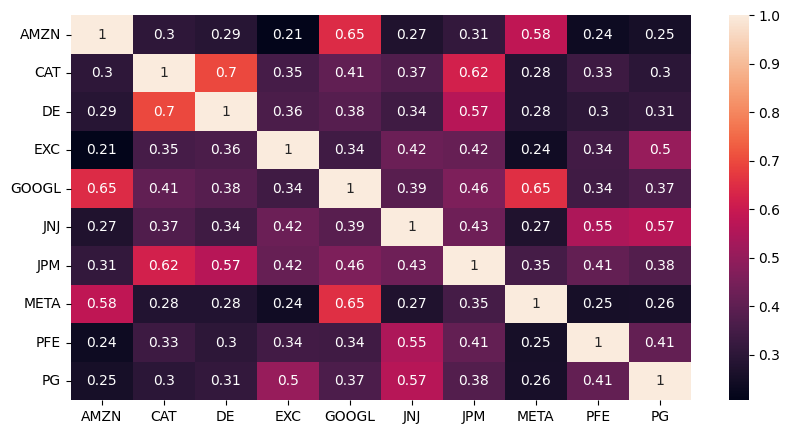

In [25]:
plt.figure(figsize = (10,5))
sns.heatmap(
    daily_returns_df.drop(columns = ["Date"]).corr(),
    annot = True
)
plt.show()

# Some scatterplot to show the correlation relationship

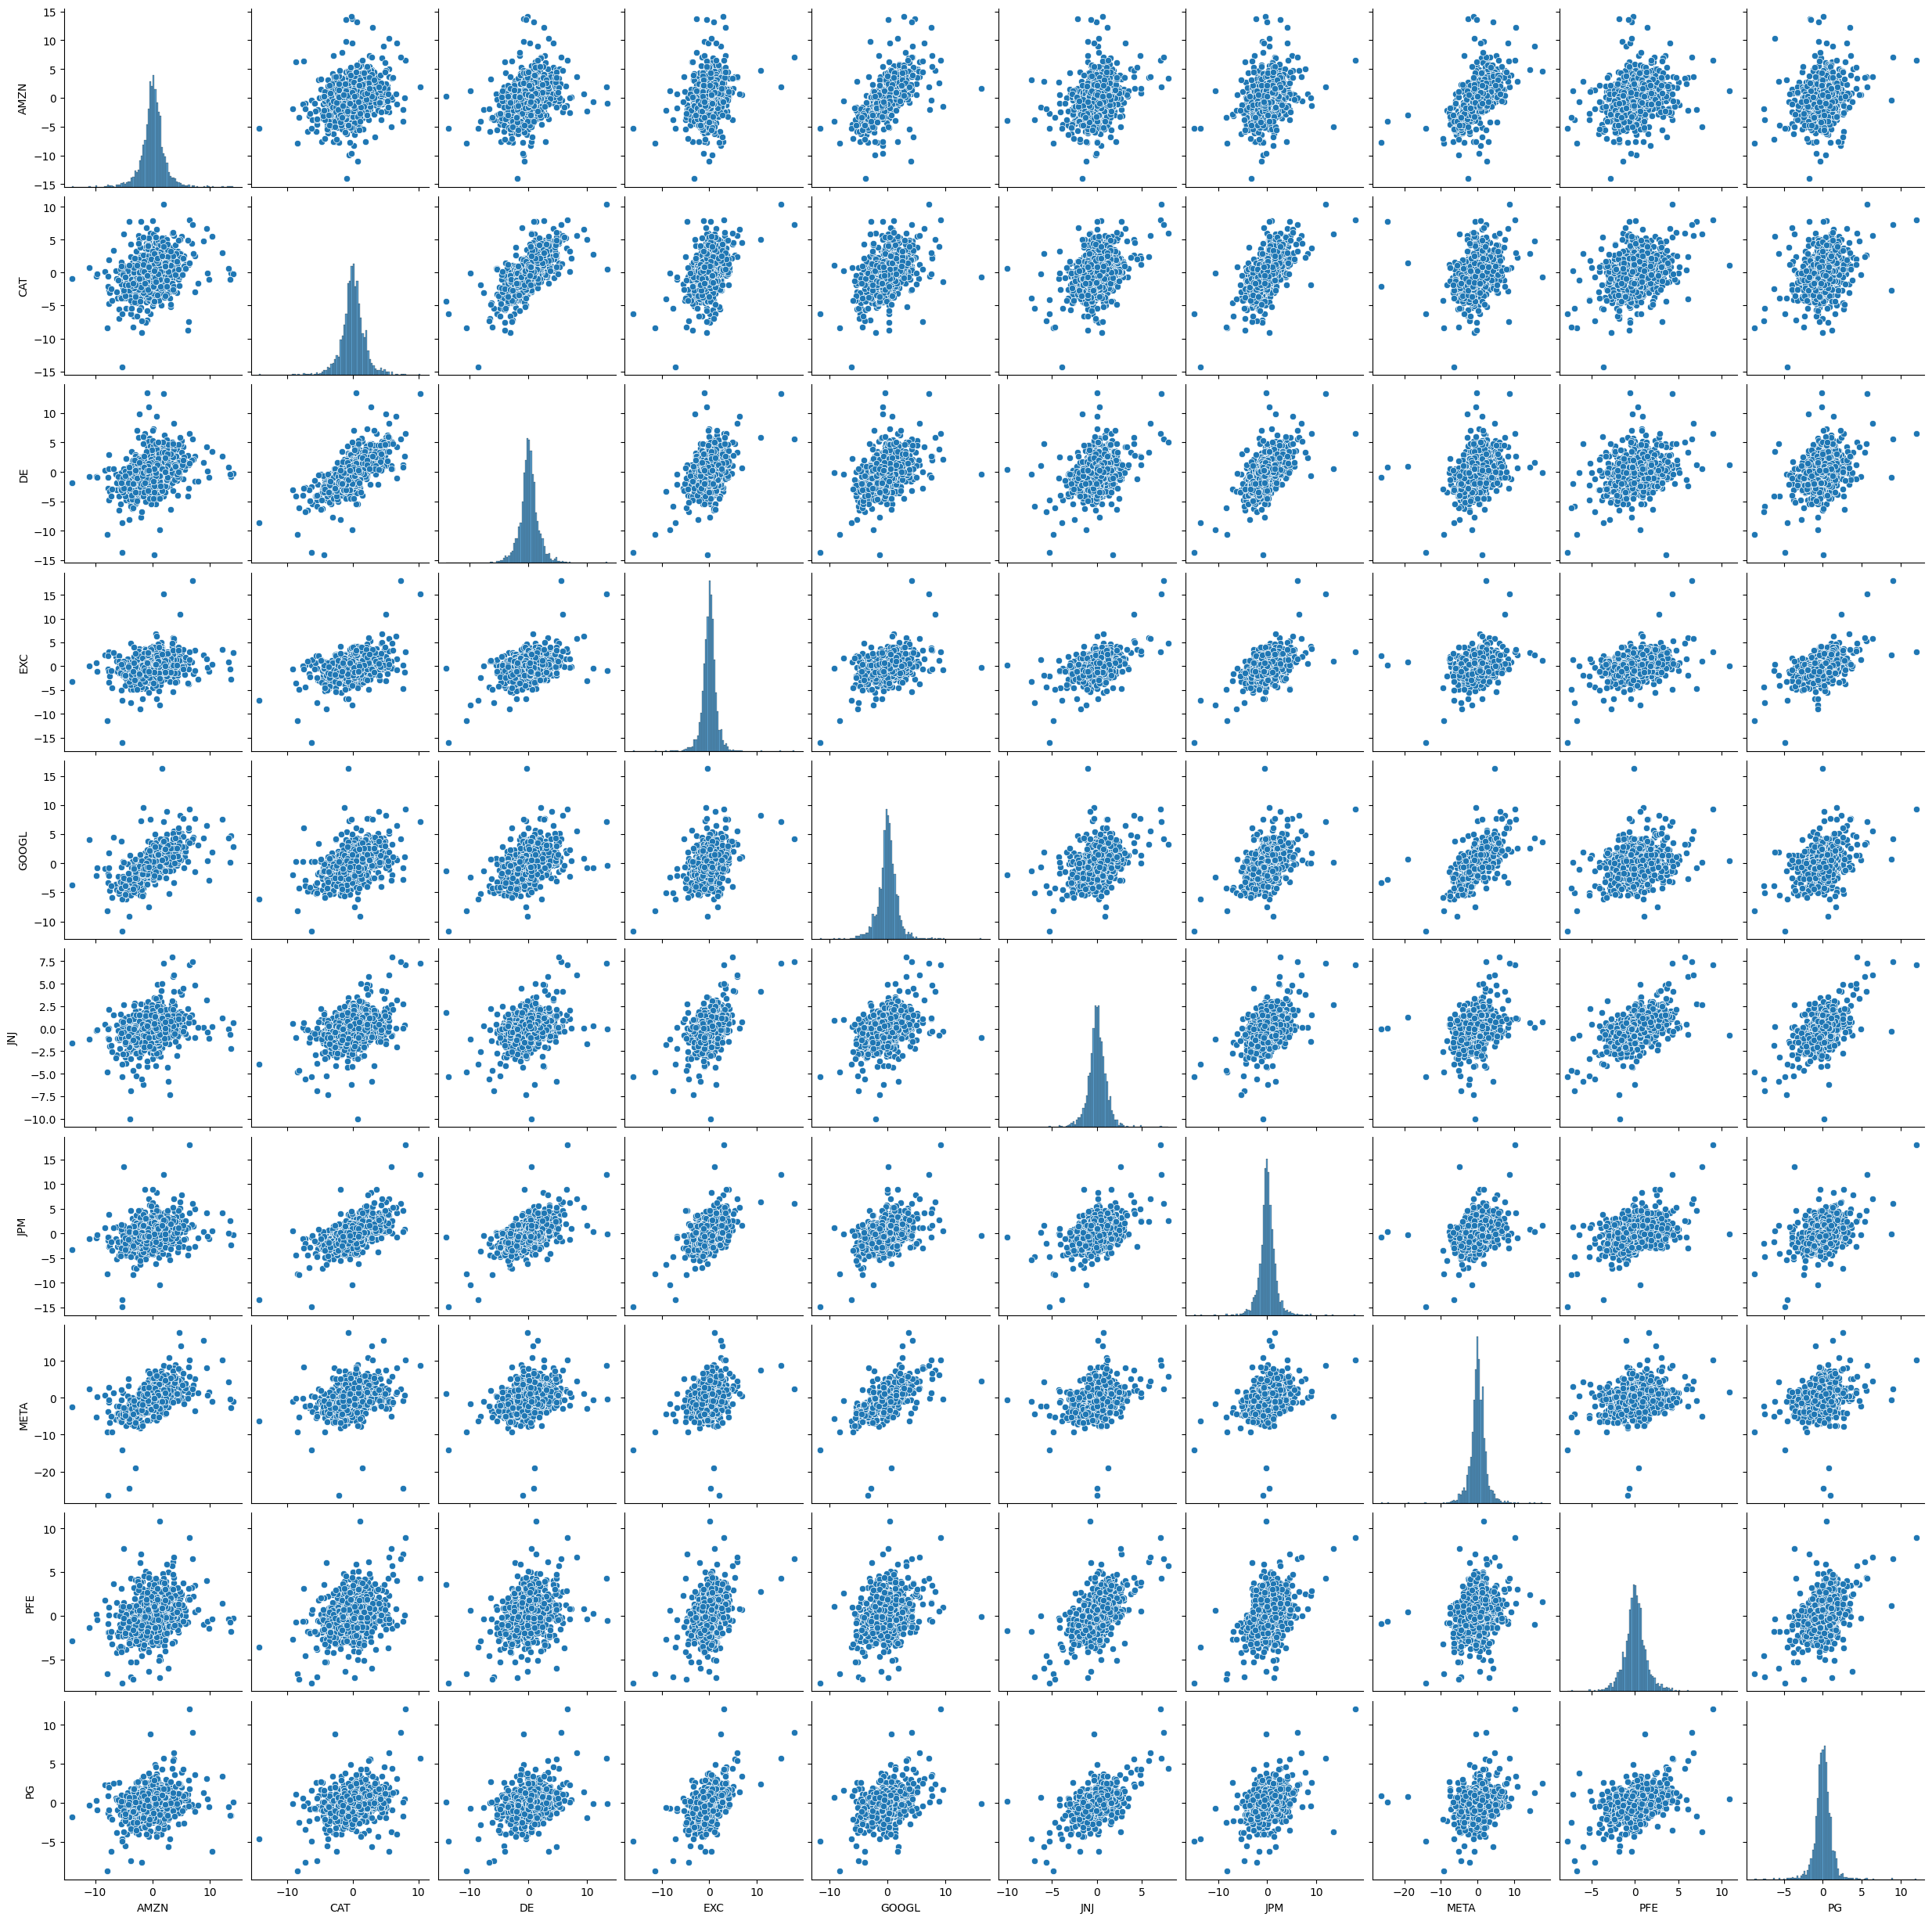

In [26]:
sns.pairplot(daily_returns_df.drop(columns = ["Date"]))
plt.show()

# Price Scaling, to make the initial stock price == 1

In [27]:
def price_scaling(raw_prices_df):
    scaled_df = raw_prices_df.copy()
    for column in raw_prices_df.columns[1:]:
        scaled_df[column] = scaled_df[column] / scaled_df[column][0]
    return scaled_df

In [28]:
price_scaling(close_price_df)

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1/3/2014,0.996155,0.999444,1.004432,0.979757,0.992705,1.009008,1.007731,0.997258,1.001970,0.998882
2,1/6/2014,0.989095,0.986314,0.996122,0.986014,1.003773,1.014281,1.013572,1.045513,1.002955,1.001242
3,1/7/2014,1.000151,0.989540,1.000554,0.991167,1.023124,1.035812,1.001890,1.058673,1.009192,1.010926
4,1/8/2014,1.009925,0.991877,0.989807,0.988958,1.025253,1.034384,1.011338,1.064339,1.016087,0.996275
...,...,...,...,...,...,...,...,...,...,...,...
2252,12/12/2022,4.550594,3.352776,5.779485,3.009701,3.349744,2.489246,2.940619,2.096692,2.498198,2.461515
2253,12/13/2022,4.648089,3.387734,5.781336,3.012534,3.433030,2.508422,2.937770,2.196125,2.541782,2.457802
2254,12/14/2022,4.602357,3.373204,5.797866,3.032362,3.412927,2.516121,2.923090,2.222446,2.609314,2.467489
2255,12/15/2022,4.445058,3.318250,5.683480,3.001203,3.261792,2.484347,2.850566,2.123012,2.567645,2.439559


# Plot using plot_financial_date on scaled price dataset

In [29]:
plot_financial_data(price_scaling(close_price_df), "Adjusted Close Stock Price on stocks")

# Random Weights Generator

In [30]:
def generate_weights(n):
    weights = []
    for i in range(n):
        weights.append(random.random())
    weights = weights / np.sum(weights)

    return weights

# Perform Assest Allocation & Calculate Portfolio Daily Return

In [31]:
weights = [0.032266, 0.094461, 0.117917, 0.132624, 0.145942, 
           0.128299, 0.10009, 0.007403, 0.088581, 0.152417]

In [32]:
portfolio_df = close_price_df.copy()
scaled_df = price_scaling(portfolio_df)
scaled_df

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1/3/2014,0.996155,0.999444,1.004432,0.979757,0.992705,1.009008,1.007731,0.997258,1.001970,0.998882
2,1/6/2014,0.989095,0.986314,0.996122,0.986014,1.003773,1.014281,1.013572,1.045513,1.002955,1.001242
3,1/7/2014,1.000151,0.989540,1.000554,0.991167,1.023124,1.035812,1.001890,1.058673,1.009192,1.010926
4,1/8/2014,1.009925,0.991877,0.989807,0.988958,1.025253,1.034384,1.011338,1.064339,1.016087,0.996275
...,...,...,...,...,...,...,...,...,...,...,...
2252,12/12/2022,4.550594,3.352776,5.779485,3.009701,3.349744,2.489246,2.940619,2.096692,2.498198,2.461515
2253,12/13/2022,4.648089,3.387734,5.781336,3.012534,3.433030,2.508422,2.937770,2.196125,2.541782,2.457802
2254,12/14/2022,4.602357,3.373204,5.797866,3.032362,3.412927,2.516121,2.923090,2.222446,2.609314,2.467489
2255,12/15/2022,4.445058,3.318250,5.683480,3.001203,3.261792,2.484347,2.850566,2.123012,2.567645,2.439559


In [33]:
initial_investment = 1000000

for index, column in enumerate(scaled_df.columns[1:]):
    portfolio_df[column] = weights[index] * scaled_df[column] * initial_investment

np.round(portfolio_df,1)

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,1/2/2014,32266.0,94461.0,117917.0,132624.0,145942.0,128299.0,100090.0,7403.0,88581.0,152417.0
1,1/3/2014,32142.0,94408.5,118439.6,129939.3,144877.4,129454.7,100863.8,7382.7,88755.5,152246.7
2,1/6/2014,31914.1,93168.2,117459.8,130769.2,146492.7,130131.3,101448.4,7739.9,88842.7,152606.2
3,1/7/2014,32270.9,93473.0,117982.3,131452.5,149316.8,132893.7,100279.2,7837.4,89395.3,154082.3
4,1/8/2014,32586.3,93693.7,116715.1,131159.6,149627.5,132710.5,101224.9,7879.3,90006.0,151849.3
...,...,...,...,...,...,...,...,...,...,...,...
2252,12/12/2022,146829.5,316706.6,681499.5,399158.6,488868.4,319367.8,294326.5,15521.8,221292.8,375176.8
2253,12/13/2022,149975.2,320008.7,681717.8,399534.3,501023.3,321828.1,294041.4,16257.9,225153.6,374610.9
2254,12/14/2022,148499.6,318636.2,683667.0,402164.0,498089.4,322815.8,292572.1,16452.8,231135.6,376087.2
2255,12/15/2022,143424.3,313445.2,670178.9,398031.6,476032.4,318739.3,285313.2,15716.7,227444.6,371830.3


# I have $100000 and I want to put my money in the 10 stocks. <br>
I will generate random weights to see the proportion of money I put in each stock respectively <br>

The function will receive: <br>
1. Dataframe consisting of closing prices
2. Weights
3. Initial Investment

The function will return: <br>
1. A dataframe consisting of 
- Daily Value of each individual stock over the time period
- Total daily value of the portfolio 
- Percentage Daily Return

In [ ]:
def asset_allocation(df, weights, initial_investment):
    portfolio_df = df.copy()
    scaled_df = price_scaling(portfolio_df)

    for index, column in enumerate(df.columns[1:]):
        portfolio_df[column] = weights[index] * scaled_df[column] * initial_investment 
    
    portfolio_df["Portfolio Value [$]"] = portfolio_df.iloc[:, 1:].sum(axis = 1, numeric_only = True)
    portfolio_df["Percentage Daily Returns [%]"] = portfolio_df["Portfolio Value [$]"].pct_change(1) * 100
    portfolio_df.replace(np.nan, 0, inplace = True)

    return portfolio_df

In [35]:
n = len(close_price_df.columns) - 1
initial_investment = 1000000
print(f"Number of Stocks under consideration: {n}")
weights = generate_weights(n)
print(f"Weights: {np.round(weights,5)}")

portfolio_df = asset_allocation(close_price_df, weights, initial_investment)
display(np.round(portfolio_df,2))


Number of Stocks under consideration: 10
Weights: [0.07459 0.14917 0.00772 0.09879 0.14322 0.13115 0.04935 0.07313 0.15885
 0.11403]


,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG,Portfolio Value [$],Percentage Daily Returns [%]
0,1/2/2014,74591.21,149165.66,7722.82,98787.37,143215.49,131151.93,49350.19,73130.59,158851.63,114033.12,1000000.00,0.00
1,1/3/2014,74304.44,149082.72,7757.05,96787.61,142170.76,132333.32,49731.71,72930.09,159164.55,113905.68,998167.92,-0.18
2,1/6/2014,73777.76,147124.15,7692.88,97405.76,143755.86,133024.93,50019.95,76458.96,159321.00,114174.70,1002755.96,0.46
3,1/7/2014,74602.45,147605.43,7727.10,97914.77,146527.23,135848.79,49443.46,77421.38,160311.84,115279.06,1012681.51,0.99
4,1/8/2014,75331.55,147954.02,7644.10,97696.58,146832.16,135661.49,49909.74,77835.76,161407.02,113608.39,1013880.82,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2252,12/12/2022,339434.32,500119.07,44633.94,297320.46,479735.28,326469.43,145120.10,153332.30,396842.75,280694.28,2963701.92,1.33
2253,12/13/2022,346706.56,505333.57,44648.24,297600.29,491663.11,328984.42,144979.52,160603.93,403766.19,280270.86,3004556.70,1.38
2254,12/14/2022,343295.36,503166.21,44775.90,299559.10,488783.99,329994.06,144255.06,162528.76,414493.73,281375.43,3012227.60,0.26
2255,12/15/2022,331562.27,494968.96,43892.51,296480.97,467139.10,325826.94,140675.99,155257.15,407874.62,278190.54,2941869.04,-2.34


# Plotting portfolio_df Percentage Daily Return

In [36]:
plot_financial_data(portfolio_df[["Date", "Percentage Daily Returns [%]"]], "Percentage Daily Returns Plot on Overall Portfolio")

# Plotting portfolio_df individual stock performance

In [37]:
plot_financial_data(portfolio_df.drop(columns = ["Portfolio Value [$]", "Percentage Daily Returns [%]"]), title = "Portfolio Individual Stock Performance")

# Plotting overall portfolio value

In [38]:
plot_financial_data(portfolio_df[['Date', 'Portfolio Value [$]']], title = "Overall Portfolio Value Growth")

# Define the "Simulation Engine" to perform assest allocation and calculate key performance metrics

# The Simulation Engine function will recieve 2 arguments
1. Portfolio Weights
2. Initial Investment Amount

# The function will return:
1. Expected Annual Returns
2. Expected Volatility 
3. Sharpe Ratio
4. Return on Investment 
5. Final Portfolio Value

In [75]:
def simulation_engine(weights, initial_investment):
    
    portfolio_df = asset_allocation(close_price_df, weights, initial_investment)
   
    daily_returns_df = portfolio_df.drop(columns = ['Date', 'Portfolio Value [$]', "Percentage Daily Returns [%]"], axis = 1).pct_change(1) 
    daily_returns_df.replace(np.nan, 0, inplace = True)

    expected_annual_returns =np.sum(weights * daily_returns_df.mean()) * 252

    covariance_matrix = daily_returns_df.cov(numeric_only = True) * 252
    expected_voltility = np.sqrt(np.dot(weights.T,np.dot(covariance_matrix, weights)))

    risk_free_returns = 4.24/100
    sharpe_ratio = (expected_annual_returns - risk_free_returns)/(expected_voltility)

    roi = ((portfolio_df['Portfolio Value [$]'][-1:] - portfolio_df['Portfolio Value [$]'][0]) / portfolio_df['Portfolio Value [$]'][0]).values[0] * 100 

    final_value = portfolio_df['Portfolio Value [$]'][-1:].values[0]

    return expected_annual_returns, expected_voltility, sharpe_ratio, roi, final_value

In [78]:
initial_investment = 1000000
portfolio_metrics = simulation_engine(weights,initial_investment)

print(f"Expected Annual Returns: {100 * portfolio_metrics[0]:.2f}%")
print(f"Expected Volatility: {100 * portfolio_metrics[1]:.2f}%")
print(f"Sharpe Ratio: {portfolio_metrics[2]:.2f}")
print(f"Return on Investment: {portfolio_metrics[3]:.2f}%")
print(f"Final Portfolio Value:${portfolio_metrics[4]:.2f}")

Expected Annual Returns: 15.20%
Expected Volatility: 17.34%
Sharpe Ratio: 0.63
Return on Investment: 192.01%
Final Portfolio Value:$2920097.68


# Monte Carlo Simulation for weights

In [110]:
def monte_carlo_simulation(n, runs, initial_investment):

    weights_runs = np.zeros((runs,n))
    sharpe_ratio_runs = np.zeros(runs)
    expected_portfolio_returns_run = np.zeros(runs)
    expected_volatility_runs = np.zeros(runs)
    roi_runs = np.zeros(runs)
    final_value_runs = np.zeros(runs)

    for i in range(runs):
        weights = generate_weights(n)
        weights_runs[i,:] = weights

        expected_portfolio_returns_run[i], expected_volatility_runs[i], sharpe_ratio_runs[i], roi_runs[i], final_value_runs[i] = simulation_engine(weights, initial_investment)
        print(f"Simulation Run Number: {i}")
        print(f"Weights: {np.round(weights,2)}, Sharpe Ratio: {sharpe_ratio_runs[i]:.2f}, Final Value: ${final_value_runs[i]:.2f}")
    
    return weights_runs, sharpe_ratio_runs, expected_portfolio_returns_run, expected_volatility_runs, roi_runs, final_value_runs

In [111]:
monte_results = monte_carlo_simulation(10, 10000, 1000000)

Simulation Run Number: 0
Weights: [0.1  0.01 0.14 0.15 0.12 0.16 0.08 0.01 0.08 0.14], Sharpe Ratio: 0.70, Final Value: $3314575.83
Simulation Run Number: 1
Weights: [0.02 0.02 0.16 0.16 0.07 0.16 0.18 0.1  0.08 0.04], Sharpe Ratio: 0.66, Final Value: $3223285.65
Simulation Run Number: 2
Weights: [0.15 0.01 0.06 0.12 0.11 0.19 0.06 0.14 0.1  0.05], Sharpe Ratio: 0.64, Final Value: $3087748.86
Simulation Run Number: 3
Weights: [0.1  0.03 0.21 0.07 0.   0.1  0.23 0.05 0.04 0.18], Sharpe Ratio: 0.69, Final Value: $3447610.20
Simulation Run Number: 4
Weights: [0.   0.16 0.   0.17 0.12 0.09 0.19 0.06 0.07 0.13], Sharpe Ratio: 0.60, Final Value: $2850436.67
Simulation Run Number: 5
Weights: [0.12 0.23 0.16 0.12 0.19 0.   0.01 0.08 0.09 0.02], Sharpe Ratio: 0.68, Final Value: $3579383.46
Simulation Run Number: 6
Weights: [0.19 0.14 0.14 0.06 0.1  0.04 0.11 0.01 0.12 0.09], Sharpe Ratio: 0.71, Final Value: $3550883.19
Simulation Run Number: 7
Weights: [0.16 0.16 0.11 0.06 0.14 0.05 0.12 0.09 0

# Markowitz Efficient Frontier
It is a plot of Expected Returns(Y) against Volatility (X)

Optimal Portfolio = Maximum Sharpe Ratio

In [117]:
monte_weight_run = monte_results[0]
monte_sharpe_runs = monte_results[1]

In [118]:
print(monte_weight_run)

[[0.10018187 0.01097077 0.14148319 ... 0.01129936 0.0832179  0.1421474 ]
 [0.02227778 0.01538491 0.16395284 ... 0.10108022 0.08445486 0.04268564]
 [0.15453142 0.01398117 0.0550289  ... 0.13818271 0.10213792 0.05011551]
 ...
 [0.00577796 0.16106753 0.09545286 ... 0.14548087 0.02761341 0.00505191]
 [0.16463544 0.02007135 0.02201438 ... 0.01638461 0.11432547 0.08718365]
 [0.1262104  0.04467461 0.06994096 ... 0.10654694 0.20784061 0.15350257]]


In [119]:
print(monte_sharpe_runs)

[0.70161082 0.65832543 0.6405611  ... 0.61478454 0.64629155 0.64491202]


# Find the index of the highest sharpe ratio (argmax()) and the value of the highest sharpe ratio (max())

In [120]:
print(f"Index of the highest sharpe ratio: {monte_sharpe_runs.argmax()}")
print(f"Value of the highest sharpe ratio: {monte_sharpe_runs.max()}")

Index of the highest sharpe ratio: 9869
Value of the highest sharpe ratio: 0.7466739468061278


In [138]:
optimal_portfolio_return, optimal_volatility, optimal_sharpe_ratio,optimal_return_on_investment, highest_final_value = simulation_engine(monte_weight_run[monte_sharpe_runs.argmax(), :], initial_investment)

In [140]:
# print(f'Best Portfolio Metrics Based on {monte_sharpe_runs.argmax()} Monte Carlo Simulation Runs:')
# print('  - Portfolio Expected Annual Return = {:.02f}%'.format(optimal_portfolio_return * 100))
# print('  - Portfolio Standard Deviation (Volatility) = {:.02f}%'.format(optimal_volatility * 100))
# print('  - Sharpe Ratio = {:.02f}'.format(optimal_sharpe_ratio))
# print('  - Final Value = ${:.02f}'.format(highest_final_value))
# print('  - Return on Investment = {:.02f}%'.format(optimal_return_on_investment))

In [ ]:
print(f"--- Best Portofolio Metrics Based on the {monte_sharpe_runs.argmax()} Monte Carlo Simulation Runs")
print(f"Portfolio Expected Annual Returns: {100 * monte_results[2][monte_sharpe_runs.argmax()]:.2f}%")
print(f"Portfolio Standard Deviation (Volatility): {100 * monte_results[3][monte_sharpe_runs.argmax()]:.2f}%")
print(f"Sharpe Ratio: {monte_results[1].max():.5f}")
print(f"Return on Investment: {monte_results[4][monte_sharpe_runs.argmax()]:.2f}%")
print(f"Final Value: ${monte_results[5][monte_sharpe_runs.argmax()]:.2f}")
print(f"Best Weights: {monte_results[0][monte_sharpe_runs.argmax()]}")

--- Best Portofolio Metrics Based on the 9869 Monte Carlo Simulation Runs
Portfolio Expected Annual Returns: 18.10%
Portfolio Standard Deviation (Volatility): 18.56%
Sharpe Ratio: 0.74667
Return on Investment: 276.40%
Final Value: $3764036.08
Best Weights: [0.2346312  0.03224698 0.21838108 0.15746418 0.04696457 0.01640233
 0.01548423 0.03930566 0.14116577 0.097954  ]


# Creating a DataFrame that contains Volatility, Expected Annual Returns, Sharpe Ratio for all simulation runs

In [149]:
sims_df = pd.DataFrame(
    {"Volatility": monte_results[3].tolist(),
     "Expected Annual Returns": monte_results[2].tolist(),
     "Sharpe Ratio": monte_results[1].tolist()
     })

display(sims_df.head())

,Volatility,Expected Annual Returns,Sharpe Ratio
0,0.168649,0.160726,0.701611
1,0.179971,0.160880,0.658325
2,0.183045,0.159651,0.640561
3,0.181258,0.167036,0.687620
4,0.180242,0.150237,0.598288


# Plot Expected Returns (Y) against Volatility (X) 

In [174]:
fig = px.scatter(
    data_frame = sims_df,
    x = "Volatility",
    y = "Expected Annual Returns",
    color = "Sharpe Ratio",
    size = "Sharpe Ratio",
    height = 500,
    width = 1000
)

fig.add_trace(
    go.Scatter(
        x = [monte_results[3][monte_sharpe_runs.argmax()]],
        y = [monte_results[2][monte_sharpe_runs.argmax()]],
        mode = 'markers',
        name = "Optimal Point",
        marker = dict(size = [40], color = 'red')
    )
)

fig.update_layout(
    template = "plotly_dark",
    coloraxis_colorbar=dict(
        title="Sharpe Ratio",
        thicknessmode="pixels", thickness=20,
        lenmode="fraction", len=0.75,
        yanchor="top", y=1,
        xanchor="left", x=1.5
))

# Highlight the point with the highest sharpe ratio^